In [6]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
import os
import nibabel as nib
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv3D, Input, MaxPooling3D, Dropout, concatenate, UpSampling3D, ReLU
import tensorflow as tf


In [47]:
print(np.__version__)

1.18.5


In [7]:
# resize와 GT resize 를 이용해서 Training 
data_path = "./BTCV_Data/1resize"
gt_path = "./BTCV_Data/gt_resize"


In [8]:
# Train과 Test를 적당한 비율로 나누는 코드(PAth 안에 값 append 시키기)

def get_dataset(data_path, gt_path):
    train_x = []
    train_y = []
    test_x = []
    test_y = []
    test_num = 6
    data_list = sorted(os.listdir(data_path))
    gt_list = sorted(os.listdir(gt_path))
    
    # Train dataset
    for i in range(0, len(data_list)-test_num):
        read_data = data_path + "/" + data_list[i]
        read_gt = gt_path + "/" + gt_list[i]
        
        voxels = nib.load(read_data).get_fdata()
        seg = nib.load(read_gt).get_fdata()
        
        # 0~1로 norm
        # voxels = voxels / 500.0
        
        train_x.append(voxels)
        train_y.append(seg)
    
    # Test dataset
    for i in range(len(data_list)-test_num, len(data_list)):
        read_data = data_path + "/" + data_list[i]
        read_gt = gt_path + "/" + gt_list[i]
        
        voxels = nib.load(read_data).get_fdata()
        seg = nib.load(read_gt).get_fdata()
        
        # voxels = voxels / 500.0
        
        test_x.append(voxels)
        test_y.append(seg)

        
    train_x = np.expand_dims(train_x, axis=-1)
    train_y = np.expand_dims(train_y, axis=-1)
    test_x = np.expand_dims(test_x, axis=-1)
    test_y = np.expand_dims(test_y, axis=-1)
    return train_x, train_y, test_x, test_y 

In [9]:
train_x, train_y, test_x, test_y = get_dataset(data_path, gt_path)

# min_value = np.min(train_x)
# max_value = np.max(train_x)

# train_x = (train_x-min_value) / (max_value-min_value)
# train_y = (train_y-min_value) / (max_value-min_value)
# test_x = (test_x-min_value) / (max_value-min_value)
# test_y = (test_y-min_value) / (max_value-min_value)

train_x = np.array(train_x)
train_y = np.array(train_y)
test_x = np.array(test_x)
test_y = np.array(test_y)

print("train x, y:", train_x.shape, train_y.shape)
print("test x, y:", test_x.shape, test_y.shape)

train x, y: (24, 128, 128, 64, 1) (24, 128, 128, 64, 1)
test x, y: (6, 128, 128, 64, 1) (6, 128, 128, 64, 1)


In [28]:
from tensorflow.python.framework.ops import disable_eager_execution
disable_eager_execution()

def dice_coef_multilabel(y_true, y_pred, labels=11):
#     y_true = tf.convert_to_tensor(y_true)
#     y_pred = tf.convert_to_tensor(y_pred)
    
    #w,h,d = y_true.shape
    result = 0
    union = (np.sum(y_pred) + np.sum(y_true))
    #print("union:" + str(union))
    intersection = 0
    for m in range(1,labels+1):
        intersection += np.sum(y_pred[y_true==m])*2.0 
    
        #print("label: "+ str(m) +" intersection: "+str(np.sum(y_pred[y_true==m])*2.0 ))
    dice = intersection / union
#     print("result: "+ str(dice))        
    
    return round(dice,2)

def dice_coef_multilabel_loss(y_true, y_pred, labels=12):
    result = 0
    union = tf.reduce_sum(tf.square(y_pred)) + tf.reduce_sum(tf.square(y_true))
    #print("union:" + str(union))
    intersection = 0
    for m in range(1,labels+1):
        intersection += 2.0 * tf.reduce_sum(y_pred==m * y_true==m)*2.0 
        #print("label: "+ str(m) +" intersection: "+str(np.sum(y_pred[y_true==m])*2.0 ))
    dice = intersection / union
#     print("result: "+ str(dice))        
    
    return 1-round(dice,2)

def dice_coef(y_true, y_pred, smooth=1):
    intersection = K.sum(y_true * y_pred, axis=[1,2,3])
    union = K.sum(y_true, axis=[1,2,3]) + K.sum(y_pred, axis=[1,2,3])
    return K.mean( (2. * intersection + smooth) / (union + smooth), axis=0)

def dice_coe(y_true,y_pred, loss_type='jaccard', smooth=1., labels=11):

    y_true_f = tf.reshape(y_true,[-1])
    y_pred_f = tf.reshape(y_pred,[-1])

    intersection = 0
    for m in range(1,labels+1):
        intersection += np.sum(y_pred[y_true==m])*2.0 

    if loss_type == 'jaccard':
        union = tf.reduce_sum(tf.square(y_pred_f)) + tf.reduce_sum(tf.square(y_true_f))

    elif loss_type == 'sorensen':
        union = tf.reduce_sum(y_pred_f) + tf.reduce_sum(y_true_f)

    else:
        raise ValueError("Unknown `loss_type`: %s" % loss_type)

    return (2. * intersection + smooth) / (union + smooth)

def dice_loss2(y_true, y_pred, loss_type='jaccard', smooth=1.):

    y_true_f = tf.cast(tf.reshape(y_true,[-1]),tf.float32)
    y_pred_f =tf.cast(tf.reshape(y_pred,[-1]),tf.float32)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    if loss_type == 'jaccard':
        union = tf.reduce_sum(tf.square(y_pred_f)) + tf.reduce_sum(tf.square(y_true_f))

    elif loss_type == 'sorensen':
        union = tf.reduce_sum(y_pred_f) + tf.reduce_sum(y_true_f)

    else:
        raise ValueError("Unknown `loss_type`: %s" % loss_type)

    return (1-(2. * intersection + smooth) / (union + smooth))

def dice_loss(y_true, y_pred, eps=0.0001):

    intersection = 2.0 * tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(tf.square(y_pred)) + tf.reduce_sum(tf.square(y_true))
    dice_score = (intersection + eps) / union
    print("intersection", intersection, union, dice_score)
    return 1.0 - dice_score

def _dice_coef_func(y_true, y_pred,
                    smooth=1, class_weight=1,
                    beta=1):
    """
    tp: True positive
    fp: False positive
    fn: False negative
    """
    tp = tf.reduce_sum(
        y_true*y_pred, axis=(0, 1, 2))
    fp = tf.reduce_sum(
        y_pred, axis=(0, 1, 2)) - tp
    fn = tf.reduce_sum(
        y_true, axis=(0, 1, 2)) - tp

    dice = (((1 + beta**2)*tp + smooth)
            /((1 + beta**2)*tp + beta**2*fn + fp + smooth))
    dice = tf.reduce_mean(dice*class_weight)
    return 1- dice

from tensorflow.keras import backend as K

def DCEL(y_true, y_pred, num_classes=2, smooth=1e-7, ignore_background=False):

    y_true = K.one_hot(K.cast(y_true, 'int32'), num_classes=num_classes)[..., 1:] if ignore_background else K.one_hot(
        K.cast(y_true, 'int32'), num_classes=num_classes)
    y_true_f = K.flatten(y_true)
    y_pred = y_pred[..., 1:] if ignore_background else y_pred
    y_pred_f = K.flatten(y_pred)

    intersect = tf.reduce_sum(y_true_f, axis=-1) * tf.reduce_sum(y_pred_f, axis=-1)
    denom = tf.reduce_sum(y_true_f, axis=-1) + tf.reduce_sum(y_pred_f, axis=-1)

    dice = K.mean((2. * intersect / (denom + smooth)))

    return 1-dice

def die(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=12)[...,1:])
    y_pred_f = K.flatten(y_pred[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)
    
    return K.mean((2. * intersect / (denom + smooth)))



In [29]:
def Unet3D(input_shape = (128,128,64)):
    
    out_channels = 11
    input_channels = 1 
    input_shape = input_shape + (input_channels,)
    x_in = layers.Input(shape=input_shape, name='input')
    
    x0 = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(x_in)
    x0 = layers.BatchNormalization()(x0)
    x0 = layers.ReLU()(x0)  # 16
    
    x1 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal')(x0)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)  # 16

    x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal')(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)  # 8

    x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal')(x2)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)  # 4

    x4 = layers.Conv3D(64, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal')(x3)
    x4 = layers.BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)  # 4
    
    # decoder [32, 32, 32, 32, 8, 8]
    x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(x4)
    x = layers.ReLU()(x)
    x = layers.UpSampling3D(size=2)(x)  # 4
    x = layers.concatenate([x, x3], axis=-1)  # 4

    x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling3D(size=2)(x)  # 8
    x = layers.concatenate([x, x2], axis=-1)  # 8

    x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling3D(size=2)(x)  # 16
    x = layers.concatenate([x, x1], axis=-1)  # 16

    x = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal')(x)
    x = layers.ReLU()(x)  # 16
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling3D(size=2)(x)  
#     x = layers.concatenate([x, x0], axis=-1)
    
    # x = layers.Conv3D(16, kernel_size=3, strides=1, padding='same')(x)
    segmentation = layers.Conv3D(out_channels+1, kernel_size=1, strides=1,
                                padding='same',
                                name='segmentation')(x)

    model = Model(inputs={'x_in': x_in}, outputs={'segmentation': segmentation}, name='Unet3D')

    return model 
    
    

In [30]:
batch_size = 4
epochs = 5
lr = 0.001  # learning rate
num_classes = 11
optimizer = tf.keras.optimizers.Adam(lr=lr, epsilon=1e-5)

In [31]:
import tensorflow
early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=50, restore_best_weights=True) 
checkpoint_path = "./seg_check_points/0725cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

In [32]:
from tensorflow import keras
model = Unet3D()
model.summary()
model.compile(optimizer=Adam(lr=lr), 
              loss= {'segmentation': die},
              metrics=[dice_coef],)



Model: "Unet3D"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input (InputLayer)              [(None, 128, 128, 64 0                                            
__________________________________________________________________________________________________
conv3d_45 (Conv3D)              (None, 128, 128, 64, 448         input[0][0]                      
__________________________________________________________________________________________________
batch_normalization_40 (BatchNo (None, 128, 128, 64, 64          conv3d_45[0][0]                  
__________________________________________________________________________________________________
re_lu_45 (ReLU)                 (None, 128, 128, 64, 0           batch_normalization_40[0][0]     
_____________________________________________________________________________________________

In [33]:
history = model.fit(train_x, train_y, epochs=epochs, validation_data=(test_x,test_y), batch_size = batch_size)

Train on 24 samples, validate on 6 samples
Epoch 1/5
24/24 [==============================] - ETA: 0s - loss: -25.4673 - dice_coef: 3.7289e-04WARNING:tensorflow:From /usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training_v1.py:2048: Model.state_updates (from tensorflow.python.keras.engine.training) is deprecated and will be removed in a future version.
Instructions for updating:
This property should not be used in TensorFlow 2.0, as updates are applied automatically.
24/24 [==============================] - 1s 59ms/sample - loss: -25.4673 - dice_coef: 3.7289e-04 - val_loss: 0.0057 - val_dice_coef: 0.1302
Epoch 2/5
24/24 [==============================] - 1s 37ms/sample - loss: 21.7403 - dice_coef: -7.2477 - val_loss: -0.0087 - val_dice_coef: 0.2335
Epoch 3/5
24/24 [==============================] - 1s 40ms/sample - loss: 2.3414 - dice_coef: -1.5068 - val_loss: 0.0419 - val_dice_coef: -0.8199
Epoch 4/5
24/24 [==============================] - 1s 38ms/sample - los

In [89]:
# test = np.squeeze(test_x)

filename1 = "./BTCV_Data/1resize/1.nii.gz"
x1 = nib.load(filename1).get_fdata()
x1 = np.expand_dims((x1), axis=-1)
output = model.predict(np.expand_dims((x1), axis=0))

result = output

result = np.squeeze(result)

result = np.argmax(result, axis=3)
print(result.shape)

a = nib.Nifti1Image(result, None) 
nib.save(a,'./BTCV_Data/seg결과1.nii.gz')

<class 'numpy.ndarray'>
(1, 128, 128, 64, 12)
(128, 128, 64, 12)
(128, 128, 64)


In [ ]:
def infer(model, image_tensor):
    image_tensor = np.expand_dims((image_tensor), axis=-1)
    predictions = model.predict(np.expand_dims((image_tensor), axis=0))
    predictions = np.squeeze(predictions)
    predictions = np.argmax(predictions, axis=3)
    return predictions

def decode_segmentation_masks(mask, colormap, n_classes):
    l0 = np.zeros_like(mask).astype(np.float32)
    l1 = np.zeros_like(mask).astype(np.float32)
    l2 = np.zeros_like(mask).astype(np.float32)
    l3 = np.zeros_like(mask).astype(np.float32)
    l4 = np.zeros_like(mask).astype(np.float32)
    l5 = np.zeros_like(mask).astype(np.float32)
    l6 = np.zeros_like(mask).astype(np.float32)
    l7 = np.zeros_like(mask).astype(np.float32)
    l8 = np.zeros_like(mask).astype(np.float32)
    l9= np.zeros_like(mask).astype(np.float32)
    l10 = np.zeros_like(mask).astype(np.float32)
    l11 = np.zeros_like(mask).astype(np.float32)
    
    for l in range(0, n_classes):
        idx = mask == l
        l0[idx] = colormap[l, 0]
        l1[idx] = colormap[l, 1]
        l2[idx] = colormap[l, 2]
        l3[idx] = colormap[l, 3]
        l4[idx] = colormap[l, 4]
        l5[idx] = colormap[l, 5]
        l6[idx] = colormap[l, 6]
        l7[idx] = colormap[l, 7]
        l8[idx] = colormap[l, 8]
        l9[idx] = colormap[l, 9]
        l10[idx] = colormap[l, 10]
        l11[idx] = colormap[l, 11]
        
    rgb = np.stack([l0, l1, l2, l3, l4, l5,6], axis=3)
    return rgb


In [64]:
model.load_weights(checkpoint_path)


Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f04d5348438> and <tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f04d5315400>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f04d5315400> and <tensorflow.python.keras.layers.advanced_activations.ReLU object at 0x7f04d53158d0>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f04d52cb278> and <tensorflow.python.keras.layers.convolutional.UpSampling3D object at 0x7f04d52b65f8>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f04d52e3f28> and <tensorflow.python.keras.layers.merge.Concatenate object at 0x7f04d52b6cf8>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.

In [113]:
model.save_weights(checkpoint_path)

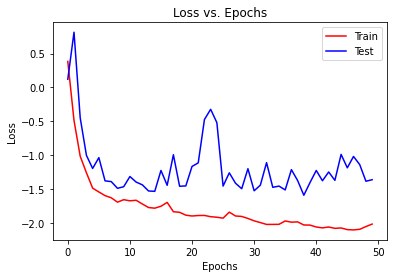

In [40]:
plt.plot(history.history['loss'], color='red', label='Train')
plt.plot(history.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()
# plt.savefig('loss_plot.png')


In [115]:
output = model.predict(test_x)
result = output['conv10']


f1model = Model(inputs=model.input, outputs=model.get_layer('conv1').output)
# f2model = Model(inputs=model.input, outputs=model.get_layer('conv2').output)
# f3model = Model(inputs=model.input, outputs=model.get_layer('conv3').output)
# f4model = Model(inputs=model.input, outputs=model.get_layer('conv4').output)
# f5model = Model(inputs=model.input, outputs=model.get_layer('conv5').output)
# f6model = Model(inputs=model.input, outputs=model.get_layer('conv6').output)
# f7model = Model(inputs=model.input, outputs=model.get_layer('conv7').output)
# f8model = Model(inputs=model.input, outputs=model.get_layer('conv8').output)
# f9model = Model(inputs=model.input, outputs=model.get_layer('conv9').output)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [78]:
def dice_coef(y_true, y_pred_bin):
                    
    intersection = 2.0 * np.sum(y_true * y_pred_bin)
    union = (np.sum(y_true) + np.sum(y_pred_bin))
    if union == 0:
        return 0
    return (intersection / union)

def dice_coef_multilabel(y_true, y_pred, labels=12):
    w,h,d = y_true.shape
    result = 0
    union = (np.sum(y_pred) + np.sum(y_true))
    #print("union:" + str(union))
    intersection = 0
    for m in range(1,labels+1):
        intersection += np.sum(y_pred[y_true==m])*2.0 
    
        #print("label: "+ str(m) +" intersection: "+str(np.sum(y_pred[y_true==m])*2.0 ))
    dice = intersection / union
#     print("result: "+ str(dice))        
    
    return round(dice,2)


filename1 = "./BTCV_Data/gt_resize/40.nii.gz"
# filename2 = "./BTCV_Data/gt_change_vox_r10/" + str(aaa) + ".nii.gz"
if os.path.isfile(filename1):

    x1 = nib.load(filename1).get_fdata()
    x1 = x1.astype(np.float32)
    x2 = nib.load(filename1).get_fdata()
    x2 = x2.astype(np.float32)

    print("Result Dice: "+ str(dice_coef_multilabel(x1,x2,11)))

Result Dice: 1.0


In [21]:
feature8 = f8model.predict(test_x)
feature9 = f9model.predict(test_x)
feature7 = f7model.predict(test_x)
feature6 = f6model.predict(test_x)
feature5 = f5model.predict(test_x)

a = feature8[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature8 24.nii.gz')

a = feature9[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature9 24.nii.gz')

a = feature7[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature7 24.nii.gz')

a = feature6[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature6 24.nii.gz')

a = feature5[0]
a = nib.Nifti1Image(a, None) 

nib.save(a,'0531 Seg 결과/feature5 24.nii.gz')



In [122]:
input_shape = (128,128,64)
input_channels = 1 
input_shape = input_shape + (input_channels,)

print(input_shape)

(128, 128, 64, 1)
